In [101]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage
import ast
import json
import re

In [102]:
def parse_model_json(content):
  if isinstance(content, dict):
    return content

  if not isinstance(content, str):
    return content

  content = content.strip()
  content = re.sub(r'^```(?:json)?\s*|\s*```$', '', content, flags=re.IGNORECASE | re.DOTALL).strip()
  match = re.search(r'\{.*\}', content, flags=re.DOTALL)
  if match:
    content = match.group(0)

  try:
    return json.loads(content)
  except json.JSONDecodeError:
    try:
      return ast.literal_eval(content)
    except (ValueError, SyntaxError):
      return content

In [103]:
load_dotenv()

True

In [104]:
class EssayEvaluatorState(TypedDict):
  essay: str
  clarity_of_thought: list[str]
  depth_of_analysis: list[str]
  language_quality: list[str]
  final_evaluator: list[str]

In [105]:
llm = ChatGroq(
  model_name="meta-llama/llama-4-scout-17b-16e-instruct",
  temperature=0,
  max_tokens=8192
)

In [106]:
def cot_agent(state: EssayEvaluatorState):
  """Determines the clarity of thought from the given essay and topic and returns the feedback and score from 1 to 10 in JSON format."""

  essay = state['essay']

  cot_agent_prompt = f"""
    You are an expert in assessing the clarity of thought of the essay.

    Analyze the essay deeply and then give the feedback and score.

    Essay: {essay}

    You are given an essay and topic and then you give the feedback on clarity of thought of the essay.

    Also give the score on clarity of thought from 1 to 10.

    Only return the JSON output. Don't even include the intro text in the response.

    Return only JSON output in this format:

    {{
      "clarity_of_thought_feedback": feedback here,
      "clarity_of_thought_score": score from 1 to 10 here as an integer 
    }}

    don't make mistakes.
  """

  response = llm.invoke([HumanMessage(content=cot_agent_prompt)])
  output = response.content
  cot = parse_model_json(output)

  return {
    "clarity_of_thought": cot
  }

In [107]:
def doa_agent(state: EssayEvaluatorState):
  """Determines the depth of analysis from the given essay and topic and returns the feedback and score from 1 to 10 in JSON format."""

  essay = state['essay']

  doa_agent_prompt = f"""
    You are an expert in assessing the depth of analysis of the essay.

    Analyze the essay deeply and then give the feedback and score.

    Essay: {essay}

    You are given an essay and then you give the feedback on depth of analysis of the essay.

    Also give the score on depth of analysis from 1 to 10.

    Only return the JSON output. Don't even include the intro text in the response.

    Return only JSON output in this format:

    {{
      "depth_of_analysis_feedback": feedback here,
      "depth_of_analysis_score": score from 1 to 10 here as an integer 
    }}

    don't make mistakes.
  """

  response = llm.invoke([HumanMessage(content=doa_agent_prompt)])
  output = response.content
  doa = parse_model_json(output)

  return {
    "depth_of_analysis": doa
  }

In [108]:
def lq_agent(state: EssayEvaluatorState):
  """Determines the language quality of the given essay and topic and returns the feedback and score from 1 to 10 in JSON format."""

  essay = state['essay']

  lq_agent_prompt = f"""
    You are an expert in assessing the language quality of the essay.

    Analyze the essay deeply and then give the feedback and score.

    Essay: {essay}

    You are given an essay and then you give the feedback on language quality of the essay.

    Also give the score on language quality from 1 to 10.

    Only return the JSON output. Don't even include the intro text in the response.

    Return only JSON output in this format:

    {{
      "language_quality_feedback": feedback here in string,
      "language_quality_score": score from 1 to 10 here as an integer 
    }}

    don't make mistakes.
  """

  response = llm.invoke([HumanMessage(content=lq_agent_prompt)])
  output = response.content
  lq = parse_model_json(output)

  return {
    "language_quality": lq
  }

In [109]:
def fianl_evaluator_agent(state: EssayEvaluatorState):
  """Determines the final feedback of the essay and returns the feedback and average score from clarity of thought score, depth of analysis score, and language quality score in JSON format."""

  essay = state['essay']
  cot = state['clarity_of_thought']
  doa = state['depth_of_analysis']
  lq = state['language_quality']

  final_evaluator_agent_prompt = f"""
    You are an expert essay evaluator. Your role is very crucial and you are the last node of the workflow.

    You have to give final feedback and average score of the essay on the basis of essay, clarity_of_thought, depth_of_analysis, and language_quality.

    Essay: {essay}
    Clarity Of Thought: {cot}
    Depth Of Analysis: {doa}
    Language Quality: {lq}

    Analyze these things / metrics deeply and then give the final feedback and average score.

    Give the average score as well

    Only return the JSON output. Don't even include the intro or outro text in the response.

    Return only JSON output in this format:

    {{
      "final_evaluator_feedback": feedback here in string,
      "final_evaluator_score": score from 1 to 10 here as float 
    }}

    don't make mistakes.
  """

  response = llm.invoke([HumanMessage(content=final_evaluator_agent_prompt)])
  output = response.content
  final_evaluator = parse_model_json(output)

  return {
    "final_evaluator": final_evaluator
  }

In [110]:
graph = StateGraph(EssayEvaluatorState)

graph.add_node('Clarity Of Thought', cot_agent)
graph.add_node('Depth Of Analysis', doa_agent)
graph.add_node('Language Quality', lq_agent)
graph.add_node('Final Evaluator', fianl_evaluator_agent)

graph.add_edge(START, "Clarity Of Thought")
graph.add_edge(START, "Depth Of Analysis")
graph.add_edge(START, "Language Quality")

graph.add_edge("Clarity Of Thought", "Final Evaluator")
graph.add_edge("Depth Of Analysis", "Final Evaluator")
graph.add_edge("Language Quality", "Final Evaluator")

graph.add_edge("Final Evaluator", END)

workflow = graph.compile()

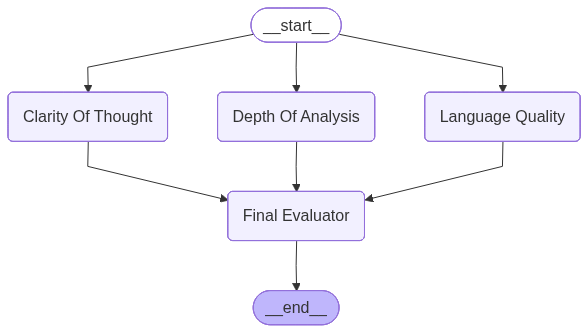

In [112]:
workflow

In [113]:
essay = f"""
  Current Adoption of Agentic AI in the Marketing and Sales Industry

Agentic AI is transforming the marketing and sales industry by moving beyond simple automation to systems that can plan, make decisions, and execute tasks with minimal human intervention. Unlike traditional AI tools that generate content or answer questions, Agentic AI can analyze data, coordinate multiple actions, and continuously improve its performance based on feedback. As businesses seek greater efficiency and personalization, many organizations are adopting AI agents to streamline customer engagement and sales processes.

In marketing, Agentic AI is widely used to deliver personalized customer experiences. AI agents analyze customer behavior, purchase history, and online interactions to recommend products, create targeted campaigns, and optimize advertising strategies in real time. They can also generate marketing content such as emails, social media posts, and product descriptions while monitoring campaign performance and automatically adjusting budgets or messaging to maximize engagement and return on investment.
"""

In [114]:
result = workflow.invoke({"essay": essay})
result

{'essay': '\n  Current Adoption of Agentic AI in the Marketing and Sales Industry\n\nAgentic AI is transforming the marketing and sales industry by moving beyond simple automation to systems that can plan, make decisions, and execute tasks with minimal human intervention. Unlike traditional AI tools that generate content or answer questions, Agentic AI can analyze data, coordinate multiple actions, and continuously improve its performance based on feedback. As businesses seek greater efficiency and personalization, many organizations are adopting AI agents to streamline customer engagement and sales processes.\n\nIn marketing, Agentic AI is widely used to deliver personalized customer experiences. AI agents analyze customer behavior, purchase history, and online interactions to recommend products, create targeted campaigns, and optimize advertising strategies in real time. They can also generate marketing content such as emails, social media posts, and product descriptions while monito